### Homework 0


In [12]:
%pip install "opencv-python" "numpy>=1.22,<2.0" --break-system-packages
%pip install scikit-image

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [13]:
import imageio
import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt
import skimage
import cv2
import os

###  1. Load the frames, convert each one to grayscale, and store them in a NumPy array of shape (N,height,width) . Show the frames as a video (use the show_video function from Lab 1.1).

In [14]:
frame_path = [os.path.join('frames', f) for f in sorted(os.listdir('frames'))]
frames = None
frames_nongray = None
for i in range(len(frame_path)):
    cur = imageio.imread(frame_path[i])
    if frames is None:
        frames = np.zeros((len(frame_path), cur.shape[0], cur.shape[1]))
    frames[i] = skimage.color.rgb2gray(cur)
    


C:\tmp\ipykernel_24460\2455691749.py:5: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  cur = imageio.imread(frame_path[i])


In [15]:
from ipywidgets import interact, IntSlider

def show_video(x,cmap=None):
    def f(i):
        plt.imshow(x[i],cmap='gray')
    interact(f, i=IntSlider(min=0, max=len(x)-1, step=1, value=0))
show_video(frames)

interactive(children=(IntSlider(value=0, description='i', max=49), Output()), _dom_classes=('widget-interact',…

### 2. Compute the per-pixel average of the video. Use np.mean() instead of a for loop to compute the average.

In [16]:
per_pixel_average = np.mean(frames, axis=0)

### 3. Show the average image, what we will call the "background" image.

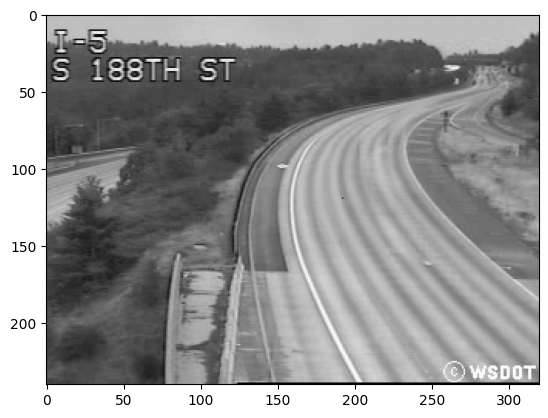

In [17]:
plt.imshow(per_pixel_average, cmap="gray")
plt.show()

### 4. Compute the absolute difference between the background image and the first frame of the video and show the result.

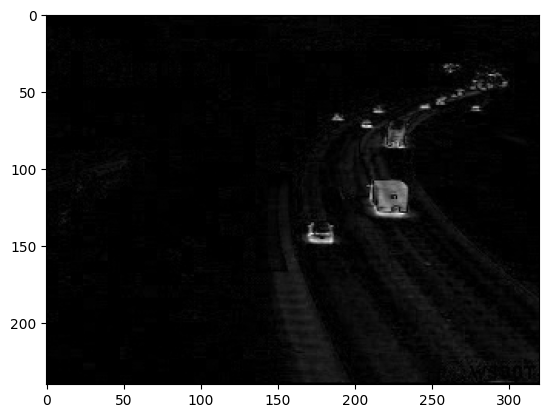

In [18]:
abs_diff = np.abs(per_pixel_average - frames[0])
plt.imshow(abs_diff, cmap="gray")
plt.show()

### 5.  Use Otsu's method to determine a good threshold for the absolute difference image.

In [19]:
_, thresh = cv2.threshold(cv2.convertScaleAbs(abs_diff * 255), 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

### 6. Threshold the absolute difference image to obtain a binary mask corresponding to the foreground pixels. Show the mask.

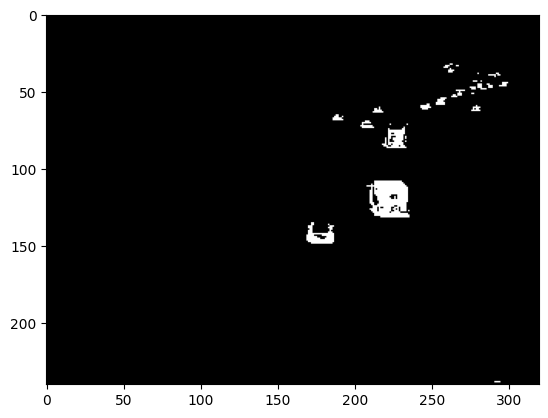

In [20]:
plt.imshow(thresh, cmap="gray")
plt.show()

### 7. Now run the thresholding technique on each frame of the video and show the result as a video.

In [21]:
threshes = [cv2.threshold(cv2.convertScaleAbs(np.abs(per_pixel_average - frame) * 255) ,0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1] for frame in frames]
show_video(threshes)

interactive(children=(IntSlider(value=0, description='i', max=49), Output()), _dom_classes=('widget-interact',…

### 8. Each connected blob in the binary mask is a car. Put a bounding box around each car and show the result as a video.

In [22]:

for i in range(len(threshes)):
    labels = skimage.measure.label(threshes[i])
    regions = skimage.measure.regionprops(labels)
    for props in regions:
        minr, minc, maxr, maxc = props.bbox
        cv2.rectangle(frames[i], (minc, minr), (maxc, maxr), (0, 0, 255), 1)
show_video(frames)

interactive(children=(IntSlider(value=0, description='i', max=49), Output()), _dom_classes=('widget-interact',…